<a href="https://colab.research.google.com/github/MonikSense/Traffic_Accident/blob/main/NE-MGCNN-Final2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Categorical Columns: ['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity', 'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition']
Numerical Columns: ['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience']

Model Comparison:

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
2              XGBoost   0.67500   0.433333  0.270833  0.333333  0.476376
3       Neural Network   0.62500   0.333333  0.250000  0.285714  0.536830
1        Random Forest   0.71875   1.000000  0.062500  0.117647  0.540737
0  Logistic Regression   0.71250   0.750000  0.062500  0.115385  0.542969
  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Ra

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


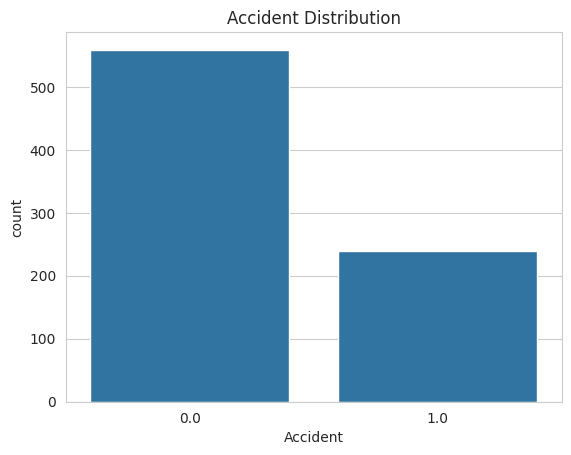

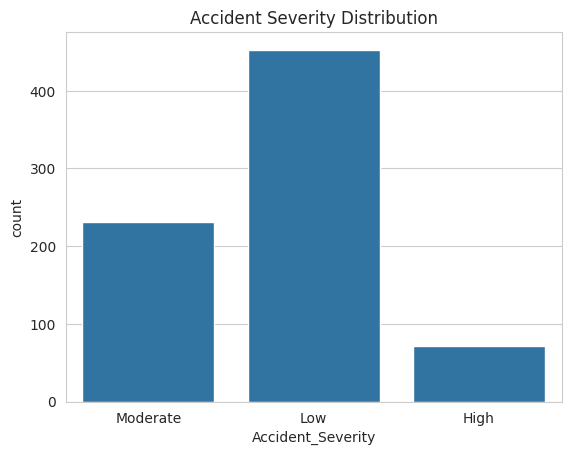

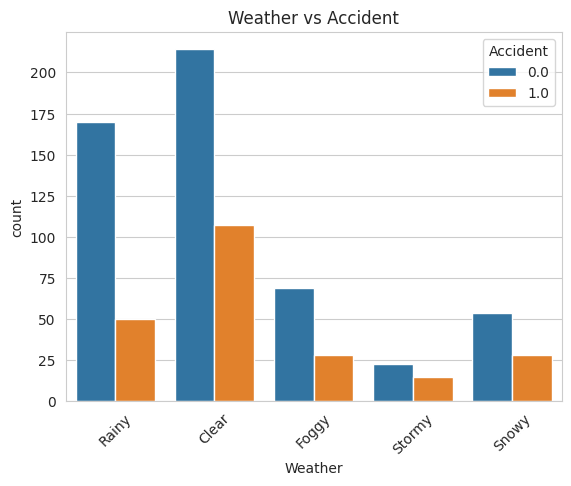

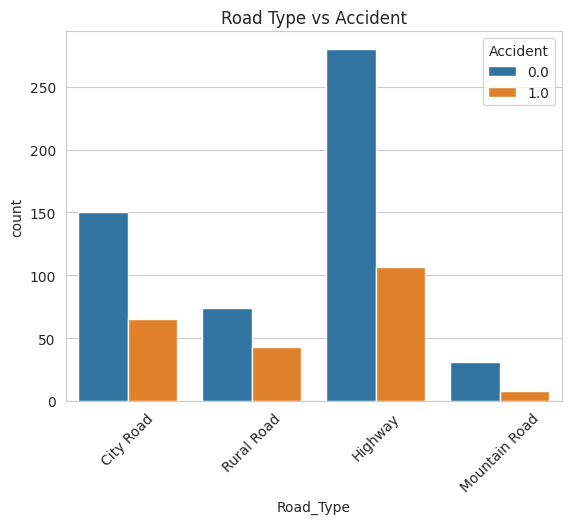

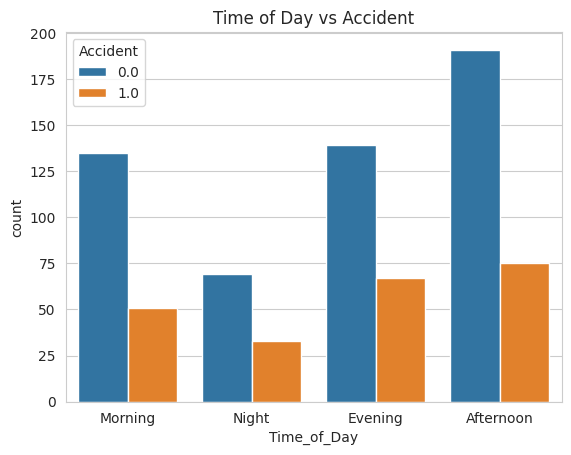

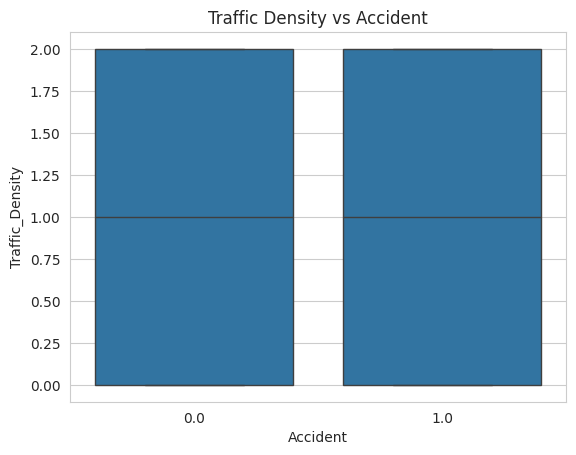

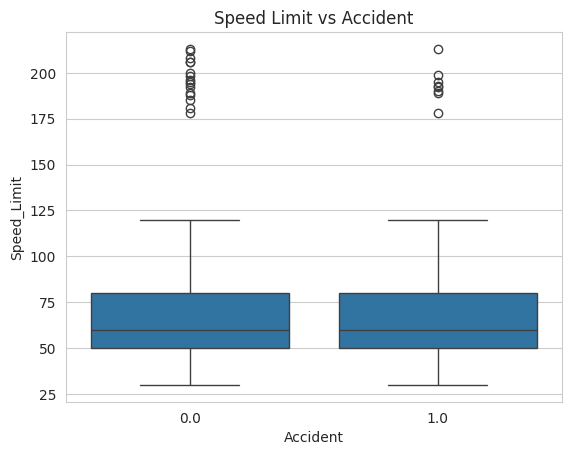

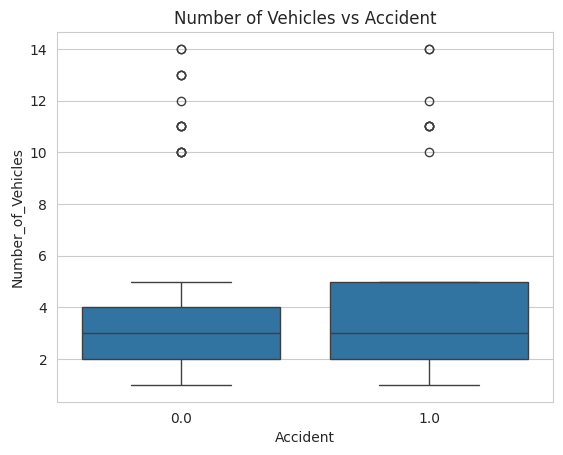

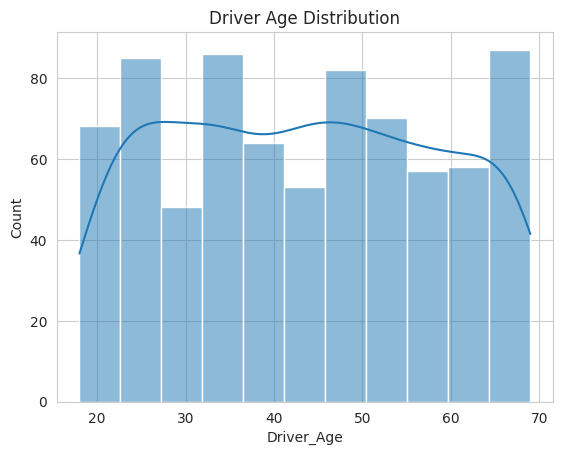

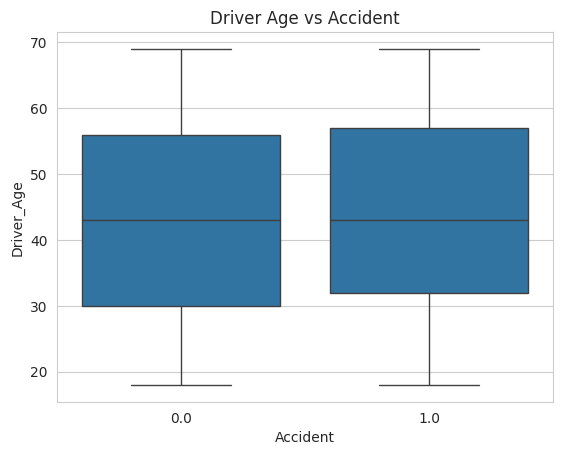

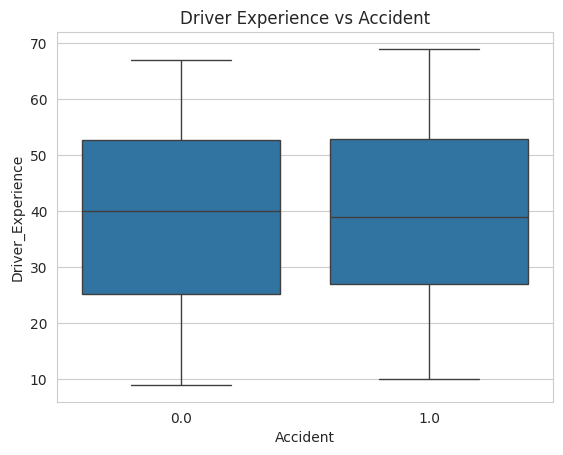

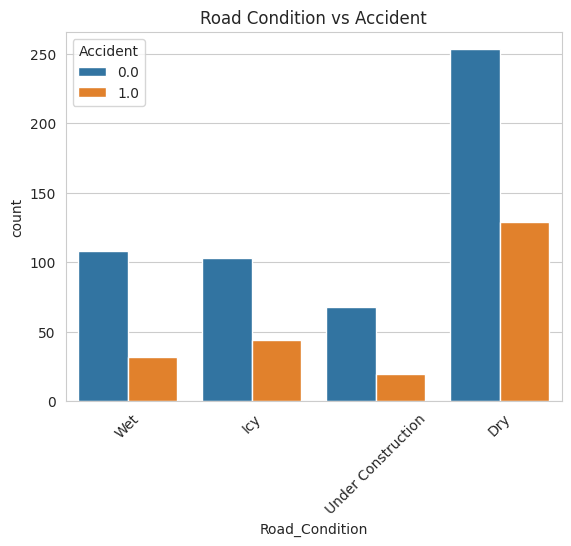

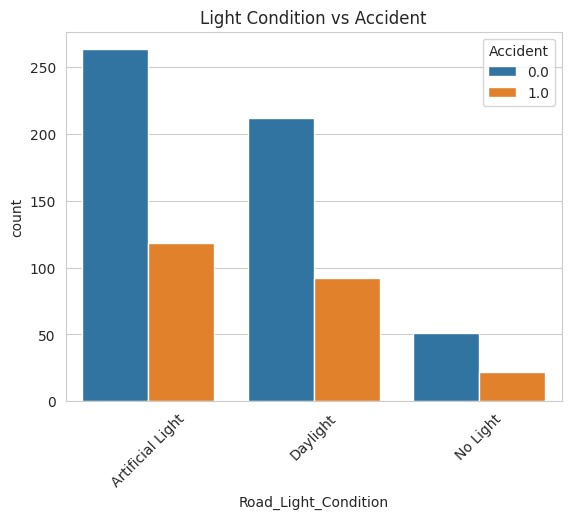

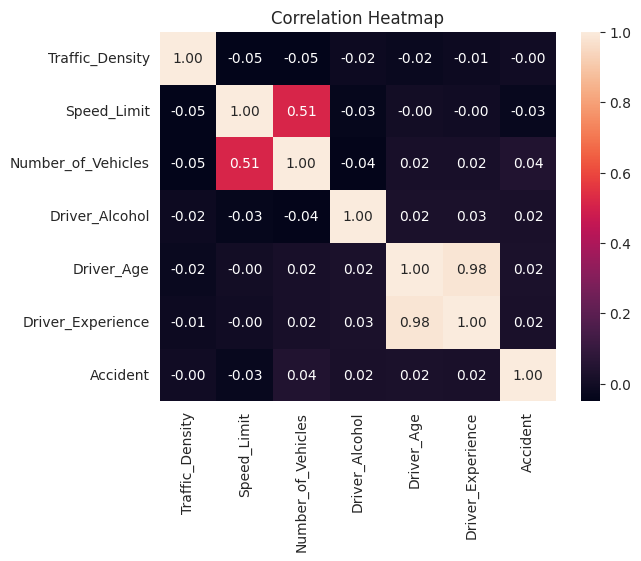

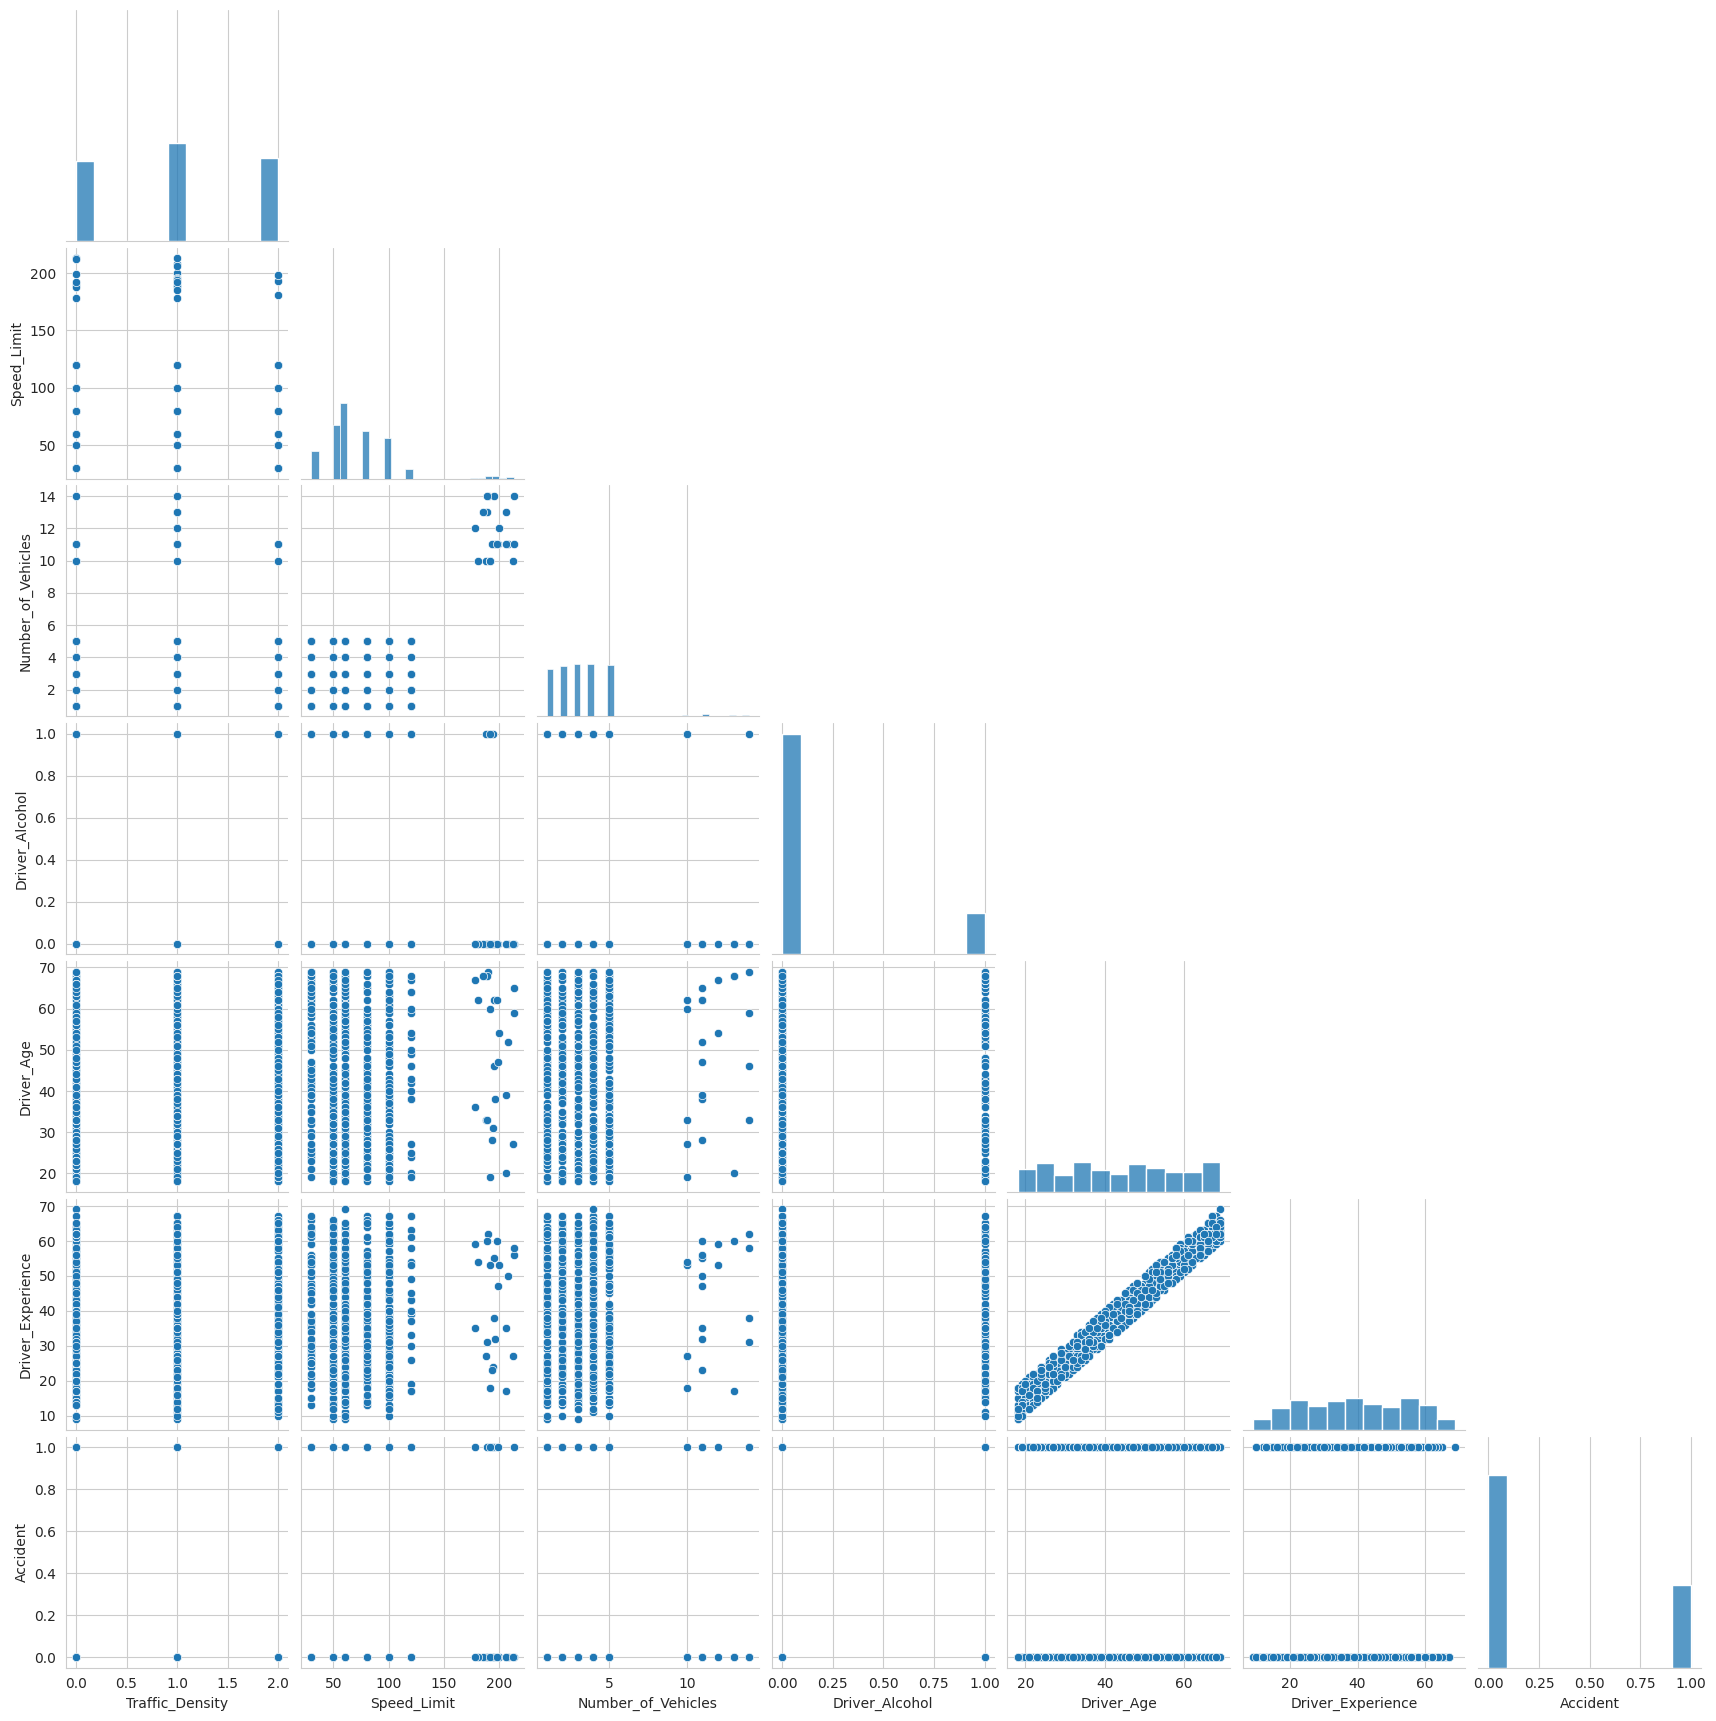

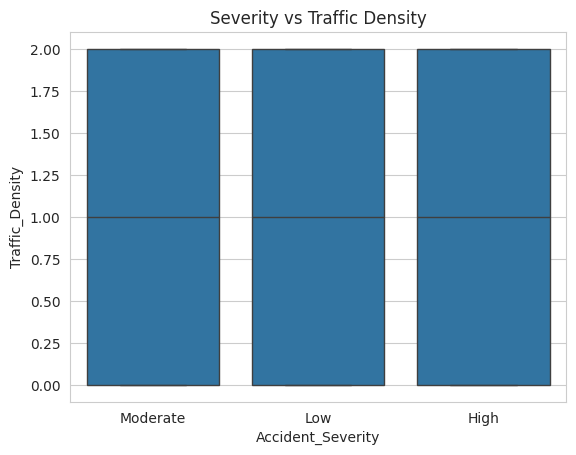

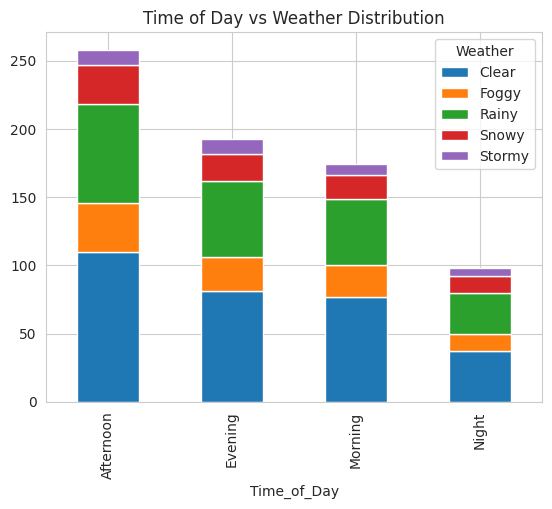

In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================================
# 2. Load Dataset
# =========================================
df = pd.read_csv("https://raw.githubusercontent.com/MonikSense/Traffic_Accident/refs/heads/main/V1-dataset_traffic_accident_prediction1.csv")

# =========================================
# 3. Define Target
# =========================================
target = "Accident"   # change if needed

# =========================================
# 4. Handle Missing Target Values (IMPORTANT FIX)
# =========================================
df = df.dropna(subset=[target])   # remove rows where target is NaN

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# =========================================
# 5. Identify Feature Types
# =========================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# =========================================
# 6. Preprocessing (Handles NaN in Features)
# =========================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),   # fill missing numeric values
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing categorical
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================================
# 7. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 8. Define Models
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

# =========================================
# 9. Training + Evaluation
# =========================================
results = []

for name, model in models.items():

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Some models may not support predict_proba properly
    if hasattr(clf.named_steps["model"], "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = 0

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([name, acc, prec, rec, f1, roc])

# =========================================
# 10. Results
# =========================================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
])

print("\nModel Comparison:\n")
print(results_df.sort_values(by="F1-score", ascending=False))


# =========================================
# 1. Import Libraries
# =========================================


sns.set_style("whitegrid")

# Clean target
df = df.dropna(subset=["Accident"])

# =========================================
# 3. Basic Info
# =========================================
print(df.head())
print(df.info())

# =========================================
# 4. Plot 1: Target Distribution
# =========================================
plt.figure()
sns.countplot(x="Accident", data=df)
plt.title("Accident Distribution")
plt.show()

# =========================================
# 5. Plot 2: Accident Severity Distribution
# =========================================
plt.figure()
sns.countplot(x="Accident_Severity", data=df)
plt.title("Accident Severity Distribution")
plt.show()

# =========================================
# 6. Plot 3: Weather vs Accident
# =========================================
plt.figure()
sns.countplot(x="Weather", hue="Accident", data=df)
plt.title("Weather vs Accident")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 7. Plot 4: Road Type vs Accident
# =========================================
plt.figure()
sns.countplot(x="Road_Type", hue="Accident", data=df)
plt.title("Road Type vs Accident")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 8. Plot 5: Time of Day vs Accident
# =========================================
plt.figure()
sns.countplot(x="Time_of_Day", hue="Accident", data=df)
plt.title("Time of Day vs Accident")
plt.show()

# =========================================
# 9. Plot 6: Traffic Density vs Accident
# =========================================
plt.figure()
sns.boxplot(x="Accident", y="Traffic_Density", data=df)
plt.title("Traffic Density vs Accident")
plt.show()

# =========================================
# 10. Plot 7: Speed Limit vs Accident
# =========================================
plt.figure()
sns.boxplot(x="Accident", y="Speed_Limit", data=df)
plt.title("Speed Limit vs Accident")
plt.show()

# =========================================
# 11. Plot 8: Number of Vehicles vs Accident
# =========================================
plt.figure()
sns.boxplot(x="Accident", y="Number_of_Vehicles", data=df)
plt.title("Number of Vehicles vs Accident")
plt.show()

# =========================================
# 12. Plot 9: Driver Age Distribution
# =========================================
plt.figure()
sns.histplot(df["Driver_Age"], kde=True)
plt.title("Driver Age Distribution")
plt.show()

# =========================================
# 13. Plot 10: Driver Age vs Accident
# =========================================
plt.figure()
sns.boxplot(x="Accident", y="Driver_Age", data=df)
plt.title("Driver Age vs Accident")
plt.show()

# =========================================
# 14. Plot 11: Experience vs Accident
# =========================================
plt.figure()
sns.boxplot(x="Accident", y="Driver_Experience", data=df)
plt.title("Driver Experience vs Accident")
plt.show()


# =========================================
# 16. Plot 13: Road Condition vs Accident
# =========================================
plt.figure()
sns.countplot(x="Road_Condition", hue="Accident", data=df)
plt.title("Road Condition vs Accident")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 17. Plot 14: Light Condition vs Accident
# =========================================
plt.figure()
sns.countplot(x="Road_Light_Condition", hue="Accident", data=df)
plt.title("Light Condition vs Accident")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 18. Plot 15: Correlation Heatmap
# =========================================
plt.figure()
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 19. Plot 16: Pairplot (Important)
# =========================================
sns.pairplot(df[numeric_df.columns], corner=True)
plt.show()

# =========================================
# 20. Plot 17: Accident Severity vs Features
# =========================================
plt.figure()
sns.boxplot(x="Accident_Severity", y="Traffic_Density", data=df)
plt.title("Severity vs Traffic Density")
plt.show()

# =========================================
# 21. Plot 18: Count of Accidents by Time & Weather
# =========================================
pivot = pd.crosstab(df["Time_of_Day"], df["Weather"])

pivot.plot(kind="bar", stacked=True)
plt.title("Time of Day vs Weather Distribution")
plt.show()